# Attempting to analyze cases

For now, eliminate pretor window and just go up until first tornado report.

In [1]:
from case_functions import *


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
from cartopy import crs as ccrs
import cartopy.feature as cfeature

# Functions

In [3]:
def hodo_plot(u_list, v_list, heights, component_range, title, color_list, label_list):
    '''
    component_range = single number, how far you want the hodograph plot to extent in m/s
    colors = list of strings of desired colors for hodograph, amount of colors must be = to # of boundary intervals
    '''
    
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    hodo = metpy.plots.Hodograph(ax, component_range=component_range)
    hodo.add_grid(increment=5)
    ax.set_xlim(-25, 5)  # Only negative x values
    ax.set_ylim(-5, 25)     
    for speed in np.arange(10, 40, 10):  # Adjust range according to your increment and component range
        x = speed / np.sqrt(2)
        y = speed / np.sqrt(2)
        ax.text(-x, y, f'{speed} m/s', color='gray', fontsize=10, ha='center', va='bottom')
    
    #colors = [[0.8,0.3,0.3,1],[0.2,0.7,0.3,1],[0.4,0.9,0.8,1], [0.7,0.4,0.7,1]]
    boundaries = [50, 500, 1000, 1500, 2000]
    
    for u, v, color, label in zip(u_list, v_list, color_list, label_list):
        h = hodo.plot_colormapped(u, v, heights, color= color, label=label, linewidth=3)
    # hodo.wind_vectors(nearfield_u_grady[0], nearfield_v_grady[0], label = 'Storm-Relative Wind Vector (m/s)')
    # hodo.wind_vectors(nearfield_u_grady[99], nearfield_v_grady[99])
    # hodo.wind_vectors(nearfield_u_grady[195], nearfield_v_grady[195])
    
    #ax.scatter(0,0, 'ko')
    ax.set_xlabel('Average U-component Wind (m/s)', fontsize=13)
    ax.set_ylabel('Average V-component Wind (m/s)', fontsize=13)
    ax.set_title(f'{title}', fontsize=13,fontweight='bold')

    for u,v in zip(u_list, v_list):
        
        for i,z in enumerate([0,45,95,195]):
            try:
                if np.isnan(u[z]):
                    pass
                else:
                    circle = plt.Circle((u[z], v[z]), radius=0.5,color='k',zorder=30)
                    ax.add_patch(circle)
                    label = ax.annotate(i, xy=(u[z], v[z]), fontsize=8, ha="center",va='center',color='white',zorder=30,weight="bold")
            except: pass
    
    ax.text(0.71, 0.96, 'Storm-Relative', transform = ax.transAxes, fontsize = 13, verticalalignment='center', color='white', bbox=dict(facecolor='blue', alpha=0.5))
    #plt.colorbar(h, label = 'Height (m above sea level)', shrink = 0.80)
    
    plt.plot(0,0, 'x', markersize = 20, label = 'Storm Motion', color = 'black', markeredgewidth = 3)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    plt.legend(loc='lower left', fontsize=13)
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/{title}', bbox_inches='tight')
    plt.show()

In [56]:
import pandas as pd
import numpy as np

def comp_per_case(csv_name, kas, dates, nf_dist, ff_dist, angle0, angle1, tor_time):
    df_all_tor = pd.DataFrame()
    df_all_nontor = pd.DataFrame()
    
    try:
        print(csv_name)
        df = pd.read_csv(csv_name)
        print(f'CSV size: {np.shape(df)}')

        # Filter data based on distance and angle
        nf = df[(df['Distance'] <= nf_dist) & (df['Angle'] <= angle1)]
        ff = df[(df['Distance'] > ff_dist) & (df['Angle'] <= angle1)]

        # Check if the dataset contains tornadic cases
        if df['Time From Tor (min)'].ne('nontor').any():
            pretor_nf = nf[nf['Time From Tor (min)'] < tor_time]
            dtor_nf = nf[nf['Time From Tor (min)'] == tor_time]
            posttor_nf = nf[nf['Time From Tor (min)'] > tor_time]

            pretor_ff = ff[ff['Time From Tor (min)'] < tor_time]
            dtor_ff = ff[ff['Time From Tor (min)'] == tor_time]
            posttor_ff = ff[ff['Time From Tor (min)'] > tor_time]

            tor_seg = [pretor_nf, dtor_nf, posttor_nf, pretor_ff, dtor_ff, posttor_ff]
            labels = ['pretor nf', 'dtor nf', 'posttor nf', 'pretor ff', 'dtor ff', 'posttor ff']
            u_or_v = ['u', 'v']

            for wind in u_or_v:
                for tor, lab in zip(tor_seg, labels):
                    seg = tor[tor['u or v'] == wind]
                    seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
                    
                    df_temp = pd.DataFrame(seg_avg).T
                    df_temp['label'] = lab
                    df_temp['wind'] = wind
                    df_temp['date'] = dates
                    df_temp['ka'] = kas
                    
                    df_all_tor = pd.concat([df_all_tor, df_temp], ignore_index=True)

        # Check if the dataset contains nontornadic cases
        if df['Time From Tor (min)'].eq('nontor').any():
            nontor_seg = [nf, ff]
            nontor_labels = ['nontor nf', 'nontor ff']
            u_or_v = ['u', 'v']

            for wind in u_or_v:
                for nontor, nonlab in zip(nontor_seg, nontor_labels):
                    ntseg = nontor[nontor['u or v'] == wind]
                    ntseg_avg = np.nanmean(ntseg.iloc[:, :196], axis=0)

                    df_temp = pd.DataFrame(ntseg_avg).T
                    df_temp['label'] = nonlab
                    df_temp['wind'] = wind
                    df_temp['date'] = dates
                    df_temp['ka'] = kas

                    df_all_nontor = pd.concat([df_all_nontor, df_temp], ignore_index=True)

    except FileNotFoundError:
        print(f"File not found: {csv_name}")
        pass

    return df_all_tor, df_all_nontor

# Dates

In [108]:
dates = ['20220523', '20220524', '20220531','20230524', '20230527', '20230609','20230612', '20240502', '20240519', '20240523', '20240602']
kas = ['ka1', 'ka2']
heights = np.arange(50, 2010, 10)

# Not composited u and v

In [109]:
df_all = pd.DataFrame()
for ka in kas:
    for d in dates:
        try:
            not_comp_file_name = f'cases/case_dfs/new/{d}_uv_{ka}_all.csv'
            print(not_comp_file_name)
            df = pd.read_csv(not_comp_file_name)
            print(np.shape(df))
            df_all = pd.concat([df_all, df], ignore_index=True)
        except FileNotFoundError:
            print(f"File not found: {not_comp_file_name}")
            continue

cases/case_dfs/new/20220523_uv_ka1_all.csv
(192, 201)
cases/case_dfs/new/20220524_uv_ka1_all.csv
(134, 201)
cases/case_dfs/new/20220531_uv_ka1_all.csv
(266, 201)
cases/case_dfs/new/20230524_uv_ka1_all.csv
File not found: cases/case_dfs/new/20230524_uv_ka1_all.csv
cases/case_dfs/new/20230527_uv_ka1_all.csv
(572, 201)
cases/case_dfs/new/20230609_uv_ka1_all.csv
(392, 201)
cases/case_dfs/new/20230612_uv_ka1_all.csv
File not found: cases/case_dfs/new/20230612_uv_ka1_all.csv
cases/case_dfs/new/20240502_uv_ka1_all.csv
File not found: cases/case_dfs/new/20240502_uv_ka1_all.csv
cases/case_dfs/new/20240519_uv_ka1_all.csv
(528, 201)
cases/case_dfs/new/20240523_uv_ka1_all.csv
(636, 201)
cases/case_dfs/new/20240602_uv_ka1_all.csv
(274, 201)
cases/case_dfs/new/20220523_uv_ka2_all.csv
(106, 201)
cases/case_dfs/new/20220524_uv_ka2_all.csv
(20, 201)
cases/case_dfs/new/20220531_uv_ka2_all.csv
File not found: cases/case_dfs/new/20220531_uv_ka2_all.csv
cases/case_dfs/new/20230524_uv_ka2_all.csv
(352, 201)

In [110]:
dist = 20
angle = 90
nf_u_all = df_all[(df_all['Distance'] <= dist) & (df_all['Angle'] <= 90) & (df_all['u or v'] == 'u')]
nf_v_all = df_all[(df_all['Distance'] <= dist) & (df_all['Angle'] <= 90) & (df_all['u or v'] == 'v')]

ff_u_all = df_all[(df_all['Distance'] > dist) & (df_all['Angle'] <= 90) & (df_all['u or v'] == 'u')]
ff_v_all = df_all[(df_all['Distance'] > dist) & (df_all['Angle'] <= 90) & (df_all['u or v'] == 'v')]

In [111]:
nf_u_all

,0,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,u or v,Distance,Angle,Time From Tor (min),Datetime
80,-18.097721,-18.205872,-18.366993,-18.564941,-18.916714,-19.110320,-19.431969,-19.743612,-20.019516,-20.237633,...,-11.867510,-11.791727,-11.656469,-11.525062,-11.406014,u,18.587774,1.972544,-1.283333,2022-05-23 23:48:43
81,-21.340527,-21.466276,-21.600838,-21.727780,-21.987421,-22.084118,-22.281563,-22.449997,-22.582027,-22.661770,...,-10.880133,-10.691040,-10.524193,-10.436994,-10.279919,u,18.798058,5.012179,-0.783333,2022-05-23 23:49:13
82,-19.205755,-19.361156,-19.540367,-19.717215,-20.046837,-20.355106,-20.467537,-20.728828,-20.933306,-21.069077,...,-7.161460,-7.113318,-7.085918,-7.018516,-6.951263,u,19.046473,44.851371,-0.3,2022-05-23 23:49:42
83,-17.985569,-18.175484,-18.325485,-18.487669,-18.773432,-18.873420,-19.081220,-19.248466,-19.349295,-19.427570,...,-6.436113,-6.401359,-6.410717,-6.350345,-6.282764,u,19.341191,47.636894,0.0,2022-05-23 23:50:12
84,0.053380,0.114234,0.166610,0.036178,-0.226589,-0.751722,-1.632881,-2.712555,-3.983265,-5.346808,...,-7.561457,-7.503475,-7.483638,-7.462274,-7.440260,u,19.712849,50.569044,0.0,2022-05-23 23:50:43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3488,-9.597390,-9.583718,-9.542200,-9.450178,-9.450178,-9.342596,-9.200231,-8.812375,-8.464844,-8.274285,...,-1.914173,-1.922345,-1.887821,-1.851556,-1.902295,u,3.101674,34.884379,nontor,2023-06-09 22:47:25
3489,-10.357672,-10.264671,-10.223030,-10.212955,-10.212955,-10.109205,-9.903680,-9.536299,-9.202655,-9.023567,...,-1.616302,-1.610529,-1.485291,-1.353712,-1.265852,u,3.512930,36.274786,nontor,2023-06-09 22:47:38
3490,-10.978352,-11.006001,-10.868601,-10.814655,-10.814655,-10.712414,-10.626690,-10.373915,-10.236437,-9.909100,...,-0.923564,-0.897285,-0.882785,-0.818236,-0.856588,u,3.918719,37.802119,nontor,2023-06-09 22:47:51
3491,-7.551372,-7.888763,-8.320932,-8.525539,-8.525539,-8.996876,-9.100043,-9.321941,-9.473623,-9.193187,...,-0.082440,-0.077795,-0.065942,-0.126762,-0.193622,u,4.353995,39.112624,nontor,2023-06-09 22:48:04


In [112]:
nf_u_all['Time From Tor (min)']

80     -1.283333
81     -0.783333
82          -0.3
83           0.0
84           0.0
          ...   
3488      nontor
3489      nontor
3490      nontor
3491      nontor
3492      nontor
Name: Time From Tor (min), Length: 471, dtype: object

In [113]:
def categorize_data(df):
    tor_time = 0
    
    # Convert 'Time From Tor (min)' to numeric, setting errors='coerce' to turn 'nontor' into NaN
    df = df.copy()  # Prevent modifying original DataFrame
    df['Time Numeric'] = pd.to_numeric(df['Time From Tor (min)'], errors='coerce')
    
    categories = {
        "nontor": df[df['Time From Tor (min)'] == 'nontor'],
        "tor": df[df['Time From Tor (min)'] != 'nontor'],
        "pretor": df[df['Time Numeric'].notna() & (df['Time Numeric'] < tor_time)],
        "dtor": df[df['Time Numeric'].notna() & (df['Time Numeric'] == tor_time)],
        "posttor": df[df['Time Numeric'].notna() & (df['Time Numeric'] > tor_time)]
    }
    
    return categories

# Apply function to each dataset
nf_u_categories = categorize_data(nf_u_all)
ff_u_categories = categorize_data(ff_u_all)
nf_v_categories = categorize_data(nf_v_all)
ff_v_categories = categorize_data(ff_v_all)

# Example usage
nf_u_categories['pretor']  # Near-field U pre-tornadic

,0,1,2,3,4,5,6,7,8,9,...,192,193,194,195,u or v,Distance,Angle,Time From Tor (min),Datetime,Time Numeric
80,-18.097721,-18.205872,-18.366993,-18.564941,-18.916714,-19.110320,-19.431969,-19.743612,-20.019516,-20.237633,...,-11.791727,-11.656469,-11.525062,-11.406014,u,18.587774,1.972544,-1.283333,2022-05-23 23:48:43,-1.283333
81,-21.340527,-21.466276,-21.600838,-21.727780,-21.987421,-22.084118,-22.281563,-22.449997,-22.582027,-22.661770,...,-10.691040,-10.524193,-10.436994,-10.279919,u,18.798058,5.012179,-0.783333,2022-05-23 23:49:13,-0.783333
82,-19.205755,-19.361156,-19.540367,-19.717215,-20.046837,-20.355106,-20.467537,-20.728828,-20.933306,-21.069077,...,-7.113318,-7.085918,-7.018516,-6.951263,u,19.046473,44.851371,-0.3,2022-05-23 23:49:42,-0.300000
803,-19.562157,-19.510490,-19.349842,-19.140547,-19.140547,-18.634007,-18.059793,-17.037962,-16.564121,-15.282240,...,12.976794,12.970767,12.955459,12.923276,u,18.126062,12.839730,-23.516667,2023-05-28 01:02:29,-23.516667
2084,-13.178982,-13.004692,-13.163273,-13.512343,-13.512343,-13.892675,-14.214121,-14.739973,-15.156748,-15.596114,...,-2.170407,-2.170407,-2.188480,-2.188480,u,16.105546,7.067678,-118.416667,2024-05-23 22:05:35,-118.416667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2224,-13.424300,-13.281560,-13.137094,-13.002065,-13.002065,-12.763414,-12.731447,-12.671892,-12.607050,-12.664352,...,-11.242197,-11.197381,-11.112547,-11.068866,u,6.105265,89.920884,-85.666667,2024-05-23 22:38:20,-85.666667
2225,-12.217471,-12.371198,-12.537816,-12.668535,-12.668535,-12.879345,-12.931458,-13.078878,-13.158925,-13.159748,...,-10.597900,-10.536954,-10.420748,-10.360304,u,6.105106,89.920503,-85.466667,2024-05-23 22:38:32,-85.466667
2226,-10.568759,-10.814757,-11.014304,-11.168557,-11.168557,-11.519385,-11.652611,-11.958336,-12.088654,-12.375460,...,-10.520666,-10.479694,-10.398476,-10.356518,u,6.105106,89.920503,-85.25,2024-05-23 22:38:45,-85.250000
2227,-11.323431,-11.438201,-11.574919,-11.745369,-11.745369,-12.059904,-12.219330,-12.502020,-12.668880,-12.936598,...,-10.457043,-10.418388,-10.331868,-10.296209,u,6.105119,89.920314,-85.033333,2024-05-23 22:38:58,-85.033333


In [114]:
pretor_u_nf = np.nanmean(nf_u_categories['pretor'].iloc[:, :196], axis=0)
pretor_v_nf = np.nanmean(nf_v_categories['pretor'].iloc[:, :196], axis=0)

dtor_u_nf = np.nanmean(nf_u_categories['dtor'].iloc[:, :196], axis=0)
dtor_v_nf = np.nanmean(nf_v_categories['dtor'].iloc[:, :196], axis=0)

posttor_u_nf = np.nanmean(nf_u_categories['posttor'].iloc[:, :196], axis=0)
posttor_v_nf = np.nanmean(nf_v_categories['posttor'].iloc[:, :196], axis=0)

nontor_u_nf = np.nanmean(nf_u_categories['nontor'].iloc[:, :196], axis=0)
nontor_v_nf = np.nanmean(nf_v_categories['nontor'].iloc[:, :196], axis=0)

In [115]:
pretor_u_ff = np.nanmean(ff_u_categories['pretor'].iloc[:, :196], axis=0)
pretor_v_ff = np.nanmean(ff_v_categories['pretor'].iloc[:, :196], axis=0)

dtor_u_ff = np.nanmean(ff_u_categories['dtor'].iloc[:, :196], axis=0)
dtor_v_ff = np.nanmean(ff_v_categories['dtor'].iloc[:, :196], axis=0)

posttor_u_ff = np.nanmean(ff_u_categories['posttor'].iloc[:, :196], axis=0)
posttor_v_ff = np.nanmean(ff_v_categories['posttor'].iloc[:, :196], axis=0)

nontor_u_ff = np.nanmean(ff_u_categories['nontor'].iloc[:, :196], axis=0)
nontor_v_ff = np.nanmean(ff_v_categories['nontor'].iloc[:, :196], axis=0)

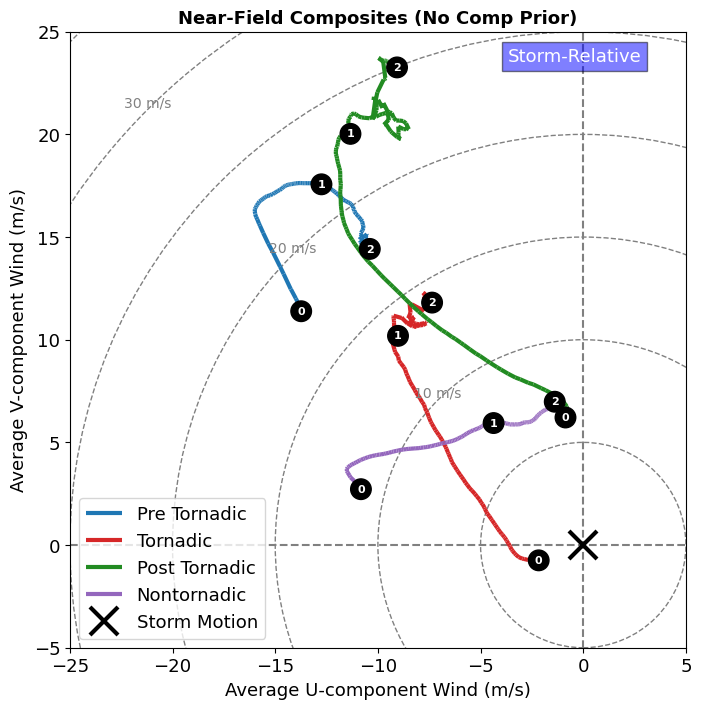

In [116]:
hodo_plot([pretor_u_nf, dtor_u_nf, posttor_u_nf, nontor_u_nf], [pretor_v_nf, dtor_v_nf, posttor_v_nf, 
                                                                             nontor_v_nf], heights, 25, 
    'Near-Field Composites (No Comp Prior)', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'])

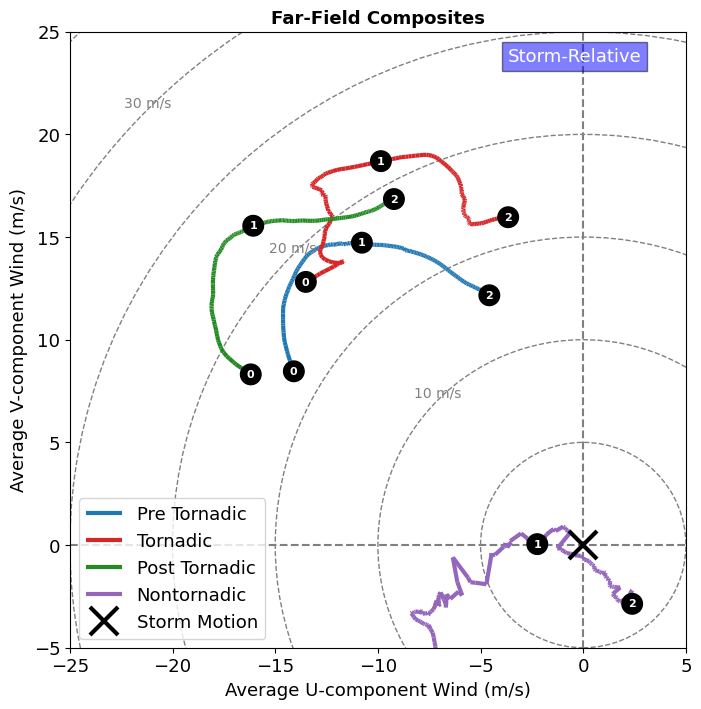

In [117]:
hodo_plot([pretor_u_ff, dtor_u_ff, posttor_u_ff, nontor_u_ff], [pretor_v_ff, dtor_v_ff, posttor_v_ff, 
                                                                             nontor_v_ff], heights, 25, 
    'Far-Field Composites', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'])

# Compositing cases

In [118]:
#csv_name = f'cases/case_dfs/new/{d}_uv_{ka}_all.csv'
nf_dist = 20
ff_dist = 20
angle0 = 0
angle1 = 90
tor_time = 0

In [119]:
comp_tor_all = pd.DataFrame()
comp_nontor_all = pd.DataFrame()

for ka in kas:
    for d in dates:
        comp_tor, comp_nontor = comp_per_case(f'cases/case_dfs/new/{d}_uv_{ka}_all.csv', ka, d, nf_dist, ff_dist, angle0, angle1, tor_time)
        comp_tor_all = pd.concat([comp_tor_all, comp_tor])
        comp_nontor_all = pd.concat([comp_nontor_all, comp_nontor])

cases/case_dfs/new/20220523_uv_ka1_all.csv
CSV size: (192, 201)
cases/case_dfs/new/20220524_uv_ka1_all.csv
CSV size: (134, 201)
cases/case_dfs/new/20220531_uv_ka1_all.csv
CSV size: (266, 201)
cases/case_dfs/new/20230524_uv_ka1_all.csv
File not found: cases/case_dfs/new/20230524_uv_ka1_all.csv
cases/case_dfs/new/20230527_uv_ka1_all.csv
CSV size: (572, 201)
cases/case_dfs/new/20230609_uv_ka1_all.csv
CSV size: (392, 201)
cases/case_dfs/new/20230612_uv_ka1_all.csv
File not found: cases/case_dfs/new/20230612_uv_ka1_all.csv
cases/case_dfs/new/20240502_uv_ka1_all.csv
File not found: cases/case_dfs/new/20240502_uv_ka1_all.csv
cases/case_dfs/new/20240519_uv_ka1_all.csv
CSV size: (528, 201)
cases/case_dfs/new/20240523_uv_ka1_all.csv
CSV size: (636, 201)
cases/case_dfs/new/20240602_uv_ka1_all.csv
CSV size: (274, 201)
cases/case_dfs/new/20220523_uv_ka2_all.csv
CSV size: (106, 201)
cases/case_dfs/new/20220524_uv_ka2_all.csv
CSV size: (20, 201)
cases/case_dfs/new/20220531_uv_ka2_all.csv
File not fou

/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_45963/2997958596.py:34: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_45963/2997958596.py:34: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_45963/2997958596.py:34: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_45963/2997958596.py:34: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_45963/2997958596.py:34: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_45963/2997958596.py:34: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :

In [120]:
comp_tor_all

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,label,wind,date,ka
0,-19.548001,-19.677768,-19.836066,-20.003312,-20.316991,-20.516515,-20.727023,-20.974146,-21.178283,-21.322827,...,-10.102059,-9.969701,-9.865362,-9.755527,-9.660191,-9.545732,pretor nf,u,20220523,ka1
1,-8.966094,-9.030625,-9.079438,-9.225745,-9.500010,-9.812571,-10.357051,-10.980510,-11.666280,-12.387189,...,-7.064530,-6.998785,-6.952417,-6.947178,-6.906309,-6.861512,dtor nf,u,20220523,ka1
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,posttor nf,u,20220523,ka1
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,pretor ff,u,20220523,ka1
4,-13.509306,-13.439182,-13.326493,-13.197410,-12.956265,-12.819045,-12.599030,-12.350593,-12.137135,-11.989006,...,-4.201586,-4.075845,-3.940926,-3.838505,-3.739524,-3.655363,dtor ff,u,20220523,ka1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,18.883110,19.097497,19.269235,19.390440,19.390440,19.643828,19.712932,19.868625,19.962659,19.923085,...,25.742552,25.701201,25.647693,25.588093,25.556673,25.546531,dtor nf,v,20230524,ka2
8,18.251055,18.322650,18.353266,18.351171,18.351171,18.416697,18.476482,18.567805,18.593894,18.686253,...,27.125443,27.134349,27.141450,27.135420,27.137770,27.124706,posttor nf,v,20230524,ka2
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,pretor ff,v,20230524,ka2
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,dtor ff,v,20230524,ka2


In [121]:
comp_tor_all.date.value_counts()

date
20220523    24
20230527    12
20240519    12
20240523    12
20240602    12
20230524    12
Name: count, dtype: int64

In [122]:
comp_tor_all.dropna(inplace=True)

In [123]:
comp_tor_all.date.value_counts()

date
20220523    10
20230527    10
20240519     8
20230524     6
20240523     4
Name: count, dtype: int64

In [124]:
comp_nontor_all.dropna(inplace=True)

In [125]:
comp_nontor_all

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,label,wind,date,ka
0,-13.948094,-13.997457,-14.054395,-14.110571,-14.225703,-14.313111,-14.425797,-14.548837,-14.671356,-14.782860,...,-6.232055,-6.156072,-6.082615,-6.011704,-5.933849,-5.872063,nontor nf,u,20220524,ka1
1,-4.835371,-4.601925,-4.440450,-4.438223,-4.301808,-4.256324,-3.946600,-3.934801,-4.194328,-4.803495,...,4.613143,4.610878,4.588439,4.573935,4.553416,4.532317,nontor ff,u,20220524,ka1
2,-1.238760,-1.167873,-1.108731,-1.064596,-0.984090,-0.983207,-0.958001,-0.950823,-0.961482,-0.981683,...,7.196328,7.222206,7.243130,7.265232,7.282131,7.299137,nontor nf,v,20220524,ka1
3,-2.312317,-1.889565,-1.453100,-0.940944,0.157580,0.307031,1.147051,1.854440,2.666419,4.491418,...,5.345037,5.348933,5.356137,5.365658,5.369675,5.389661,nontor ff,v,20220524,ka1
0,-7.405243,-7.356374,-7.288989,-7.220995,-7.089597,-6.975663,-6.799171,-6.549673,-6.211954,-5.797939,...,8.190941,8.142107,8.102045,8.068398,8.018842,7.974552,nontor nf,u,20220531,ka1
1,-7.460519,-7.559646,-7.635677,-7.680277,-7.789530,-7.792088,-7.832245,-7.868394,-7.902813,-7.944899,...,-3.854600,-3.788412,-3.773265,-3.720772,-3.830280,-3.899634,nontor ff,u,20220531,ka1
2,-5.320863,-5.092955,-4.869718,-4.702218,-4.429097,-4.296373,-4.028881,-3.769073,-3.593487,-3.476391,...,-1.996225,-2.014550,-1.988070,-1.970134,-1.990404,-2.016382,nontor nf,v,20220531,ka1
3,-6.572519,-6.404315,-6.223722,-6.082679,-5.822495,-5.692801,-5.468965,-5.255068,-5.064986,-4.916553,...,-8.114915,-8.270854,-8.651482,-8.753448,-8.731653,-8.503512,nontor ff,v,20220531,ka1
0,-11.455199,-11.596892,-11.710136,-11.800275,-11.800275,-11.989248,-12.032881,-12.135600,-12.186123,-12.215212,...,-2.127313,-2.113066,-2.098277,-2.081821,-2.071527,-2.059869,nontor nf,u,20230609,ka1
2,4.874416,5.003637,5.112247,5.204979,5.204979,5.397539,5.463081,5.605109,5.674939,5.777151,...,8.774946,8.799850,8.825601,8.844327,8.872956,8.888677,nontor nf,v,20230609,ka1


In [126]:
pretor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'pretor nf')].iloc[:, :196], axis=0)
pretor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'pretor nf')].iloc[:, :196], axis=0)

dtor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'dtor nf')].iloc[:, :196], axis=0)
dtor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'dtor nf')].iloc[:, :196], axis=0)

posttor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'posttor nf')].iloc[:, :196], axis=0)
posttor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'posttor nf')].iloc[:, :196], axis=0)

pretor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'pretor ff')].iloc[:, :196], axis=0)
pretor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'pretor ff')].iloc[:, :196], axis=0)

dtor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'dtor ff')].iloc[:, :196], axis=0)
dtor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'dtor ff')].iloc[:, :196], axis=0)

posttor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'posttor ff')].iloc[:, :196], axis=0)
posttor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'posttor ff')].iloc[:, :196], axis=0)

In [127]:
nontor_u_nf = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'u') & (comp_nontor_all['label'] == 'nontor nf')].iloc[:, :196], axis=0)
nontor_v_nf = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'v') & (comp_nontor_all['label'] == 'nontor nf')].iloc[:, :196], axis=0)

nontor_u_ff = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'u') & (comp_nontor_all['label'] == 'nontor ff')].iloc[:, :196], axis=0)
nontor_v_ff = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'v') & (comp_nontor_all['label'] == 'nontor ff')].iloc[:, :196], axis=0)


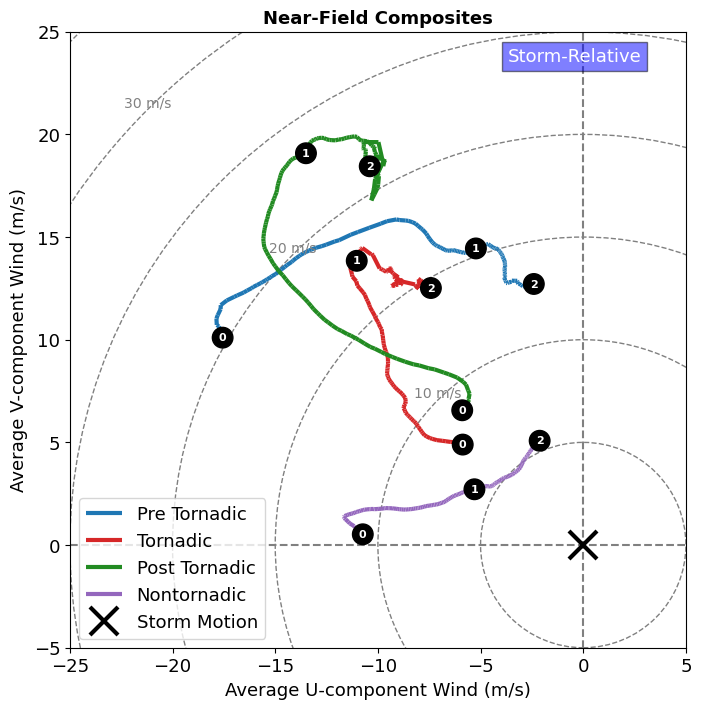

In [128]:
hodo_plot([pretor_u_nf, dtor_u_nf, posttor_u_nf, nontor_u_nf], [pretor_v_nf, dtor_v_nf, posttor_v_nf, 
                                                                             nontor_v_nf], heights, 25, 
    'Near-Field Composites', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'])

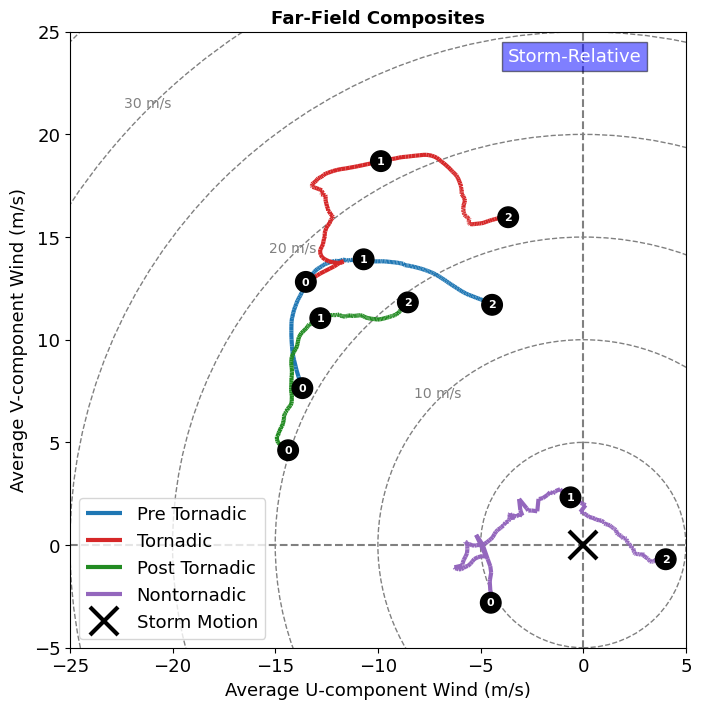

In [129]:
hodo_plot([pretor_u_ff, dtor_u_ff, posttor_u_ff, nontor_u_ff], [pretor_v_ff, dtor_v_ff, posttor_v_ff, 
                                                                             nontor_v_ff], heights, 25, 
    'Far-Field Composites', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'])